# Transfer Learning

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import torch
import random

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

from sklearn.metrics import accuracy_score, f1_score
from scripts.load import PROCESSED_DIR, MODEL_DIR, make_loader, sample_labels, make_confusion
from src.models import Encoder, Classifier
from scripts.train_cls import train_classifier

In [2]:
data = np.load(PROCESSED_DIR / 'splits.npz')

X_train = data['X_train'] # 70%
X_val   = data['X_val'] # 10 %
X_test  = data['X_test']
y_train = data['y_train']
y_val   = data['y_val'] # 10 %
y_test  = data['y_test']

train_loader = make_loader(X_val, y_val, batch_size=128, shuffle=True) # 10% data
test_loader   = make_loader(X_test, y_test, batch_size=128) # 20% data

train_loader_ssl = make_loader(X_train, batch_size=128, shuffle=True)

## AE

In [3]:
device = "cpu"
encoder_ae = Encoder()
encoder_ae.load_state_dict(torch.load(MODEL_DIR / "encoder_ae.pth"))

model_ae, train_losses_ae, val_losses_ae, val_accs_ae = train_classifier(
    encoder_ae,
    train_loader,
    test_loader,
    epochs=20,
    device=device
)

torch.save(model_ae.state_dict(), MODEL_DIR / "cls_ae_full.pth")

Epoch 1 | Train Loss: 2.3793 | Val Loss: 2.8480 | Val Acc: 0.1742
Epoch 2 | Train Loss: 1.9048 | Val Loss: 2.7561 | Val Acc: 0.2692
Epoch 3 | Train Loss: 1.6290 | Val Loss: 2.5375 | Val Acc: 0.3706
Epoch 4 | Train Loss: 1.3956 | Val Loss: 2.0607 | Val Acc: 0.3875
Epoch 5 | Train Loss: 1.2625 | Val Loss: 1.3742 | Val Acc: 0.5718
Epoch 6 | Train Loss: 1.1135 | Val Loss: 1.1558 | Val Acc: 0.5489
Epoch 7 | Train Loss: 1.0242 | Val Loss: 1.0741 | Val Acc: 0.6198
Epoch 8 | Train Loss: 0.9297 | Val Loss: 0.9203 | Val Acc: 0.6446
Epoch 9 | Train Loss: 0.8674 | Val Loss: 0.8932 | Val Acc: 0.6930
Epoch 10 | Train Loss: 0.8196 | Val Loss: 1.1402 | Val Acc: 0.5600
Epoch 11 | Train Loss: 0.7705 | Val Loss: 1.3088 | Val Acc: 0.5014
Epoch 12 | Train Loss: 0.7160 | Val Loss: 0.7540 | Val Acc: 0.6973
Epoch 13 | Train Loss: 0.6509 | Val Loss: 0.7638 | Val Acc: 0.7243
Epoch 14 | Train Loss: 0.6108 | Val Loss: 0.8073 | Val Acc: 0.6687
Epoch 15 | Train Loss: 0.5751 | Val Loss: 1.5164 | Val Acc: 0.4754
Epoc

## Evaluate AE

In [4]:
def evaluate(model, loader, device="cpu"):
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = model(X)
            preds = out.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')

    return acc, f1

In [5]:
encoder_ae = Encoder()
model_ae = Classifier(encoder_ae).to("cpu")

model_ae.load_state_dict(torch.load(MODEL_DIR / "cls_ae_full.pth"))

test_acc, test_f1 = evaluate(model_ae, test_loader)

print("AE Full -> Test Acc:", test_acc)
print("AE Full -> Test F1 :", test_f1)

AE Full -> Test Acc: 0.7243373493975903
AE Full -> Test F1 : 0.6714568370194479


## AE on 20% val

In [6]:
X_small, y_small = sample_labels(X_val, y_val, fraction=0.2)
train_loader_small = make_loader(X_small, y_small, batch_size=128, shuffle=True)

In [7]:
ae_small = Encoder()
ae_small.load_state_dict(torch.load(MODEL_DIR / "encoder_ae.pth"))

model_small, train_losses_ae20, val_losses_ae20, val_accs_ae20 = train_classifier(
    ae_small,
    train_loader_small,
    test_loader,
    epochs=20,
    device="cpu"
)

torch.save(model_small.state_dict(), MODEL_DIR / "cls_ae_20.pth")

Epoch 1 | Train Loss: 2.8508 | Val Loss: 2.8777 | Val Acc: 0.0152
Epoch 2 | Train Loss: 2.5060 | Val Loss: 2.8709 | Val Acc: 0.0899
Epoch 3 | Train Loss: 2.3459 | Val Loss: 2.8614 | Val Acc: 0.0899
Epoch 4 | Train Loss: 2.2178 | Val Loss: 2.8531 | Val Acc: 0.1222
Epoch 5 | Train Loss: 2.0827 | Val Loss: 2.8471 | Val Acc: 0.0986
Epoch 6 | Train Loss: 1.9981 | Val Loss: 2.8365 | Val Acc: 0.1810
Epoch 7 | Train Loss: 1.8826 | Val Loss: 2.8121 | Val Acc: 0.2075
Epoch 8 | Train Loss: 1.8463 | Val Loss: 2.7925 | Val Acc: 0.2566
Epoch 9 | Train Loss: 1.8088 | Val Loss: 2.7562 | Val Acc: 0.3154
Epoch 10 | Train Loss: 1.6589 | Val Loss: 2.6990 | Val Acc: 0.3400
Epoch 11 | Train Loss: 1.5762 | Val Loss: 2.6599 | Val Acc: 0.3130
Epoch 12 | Train Loss: 1.5637 | Val Loss: 2.5826 | Val Acc: 0.3598
Epoch 13 | Train Loss: 1.4541 | Val Loss: 2.5224 | Val Acc: 0.3333
Epoch 14 | Train Loss: 1.3983 | Val Loss: 2.3883 | Val Acc: 0.3947
Epoch 15 | Train Loss: 1.3751 | Val Loss: 2.2658 | Val Acc: 0.3812
Epoc

In [8]:
encoder_small = Encoder()
model_small = Classifier(encoder_small).to(device="cpu")

model_small.load_state_dict(torch.load(MODEL_DIR / "cls_ae_20.pth"))

test_acc, test_f1 = evaluate(model_small, test_loader)

print("MAE 20% -> Test Acc:", test_acc)
print("MAE 20% -> Test F1 :", test_f1)

MAE 20% -> Test Acc: 0.46481927710843374
MAE 20% -> Test F1 : 0.3272833852747807


## MAE

In [9]:
device = "cpu"
encoder_mae = Encoder()
encoder_mae.load_state_dict(torch.load(MODEL_DIR / "encoder_mae.pth"))

model_mae, train_losses_mae, val_losses_mae, val_accs_mae = train_classifier(
    encoder_mae,
    train_loader,
    test_loader,
    epochs=20,
    device=device
)

torch.save(model_mae.state_dict(), MODEL_DIR / "cls_mae_full.pth")

Epoch 1 | Train Loss: 2.1945 | Val Loss: 2.6477 | Val Acc: 0.3749
Epoch 2 | Train Loss: 1.6312 | Val Loss: 2.1596 | Val Acc: 0.5294
Epoch 3 | Train Loss: 1.3690 | Val Loss: 1.6497 | Val Acc: 0.5689
Epoch 4 | Train Loss: 1.1914 | Val Loss: 1.1541 | Val Acc: 0.6576
Epoch 5 | Train Loss: 1.0544 | Val Loss: 0.9842 | Val Acc: 0.6937
Epoch 6 | Train Loss: 0.9439 | Val Loss: 0.9125 | Val Acc: 0.7123
Epoch 7 | Train Loss: 0.8671 | Val Loss: 0.7637 | Val Acc: 0.7506
Epoch 8 | Train Loss: 0.8126 | Val Loss: 0.7966 | Val Acc: 0.7359
Epoch 9 | Train Loss: 0.7187 | Val Loss: 0.7564 | Val Acc: 0.7289
Epoch 10 | Train Loss: 0.6423 | Val Loss: 0.6361 | Val Acc: 0.7766
Epoch 11 | Train Loss: 0.6210 | Val Loss: 0.7148 | Val Acc: 0.7120
Epoch 12 | Train Loss: 0.5859 | Val Loss: 0.7496 | Val Acc: 0.7337
Epoch 13 | Train Loss: 0.5517 | Val Loss: 0.6410 | Val Acc: 0.7908
Epoch 14 | Train Loss: 0.5082 | Val Loss: 0.6083 | Val Acc: 0.7795
Epoch 15 | Train Loss: 0.4743 | Val Loss: 0.5432 | Val Acc: 0.8067
Epoc

In [10]:
encoder = Encoder()
model = Classifier(encoder).to("cpu")

model.load_state_dict(torch.load(MODEL_DIR / "cls_mae_full.pth"))

test_acc, test_f1 = evaluate(model, test_loader)

print("MAE Full -> Test Acc:", test_acc)
print("MAE Full -> Test F1 :", test_f1)

MAE Full -> Test Acc: 0.8371084337349397
MAE Full -> Test F1 : 0.8466771443819144


## MAE on 20% of val

In [11]:
encoder = Encoder()
encoder.load_state_dict(torch.load(MODEL_DIR / "encoder_mae.pth"))

model_small, train_losses_mae20, val_losses_mae20, val_accs_mae20 = train_classifier(
    encoder,
    train_loader_small,
    test_loader,
    epochs=20,
    device=device
)

torch.save(model_small.state_dict(), MODEL_DIR / "cls_mae_20.pth")

Epoch 1 | Train Loss: 2.8319 | Val Loss: 2.8640 | Val Acc: 0.1665
Epoch 2 | Train Loss: 2.4371 | Val Loss: 2.8216 | Val Acc: 0.1976
Epoch 3 | Train Loss: 2.1502 | Val Loss: 2.7646 | Val Acc: 0.3002
Epoch 4 | Train Loss: 2.0135 | Val Loss: 2.7027 | Val Acc: 0.3489
Epoch 5 | Train Loss: 1.8698 | Val Loss: 2.6214 | Val Acc: 0.3701
Epoch 6 | Train Loss: 1.7194 | Val Loss: 2.5187 | Val Acc: 0.3899
Epoch 7 | Train Loss: 1.6201 | Val Loss: 2.4224 | Val Acc: 0.4239
Epoch 8 | Train Loss: 1.5863 | Val Loss: 2.3185 | Val Acc: 0.4802
Epoch 9 | Train Loss: 1.4422 | Val Loss: 2.2062 | Val Acc: 0.4665
Epoch 10 | Train Loss: 1.4412 | Val Loss: 2.1013 | Val Acc: 0.5067
Epoch 11 | Train Loss: 1.2812 | Val Loss: 2.0133 | Val Acc: 0.5557
Epoch 12 | Train Loss: 1.3026 | Val Loss: 1.8390 | Val Acc: 0.5316
Epoch 13 | Train Loss: 1.1567 | Val Loss: 1.7297 | Val Acc: 0.5624
Epoch 14 | Train Loss: 1.1560 | Val Loss: 1.5889 | Val Acc: 0.5872
Epoch 15 | Train Loss: 1.0561 | Val Loss: 1.4732 | Val Acc: 0.5945
Epoc

In [12]:
encoder = Encoder()
model_small = Classifier(encoder).to(device="cpu")

model_small.load_state_dict(torch.load(MODEL_DIR / "cls_mae_20.pth"))

test_acc, test_f1 = evaluate(model_small, test_loader)

print("MAE 20% -> Test Acc:", test_acc)
print("MAE 20% -> Test F1 :", test_f1)

MAE 20% -> Test Acc: 0.6720481927710843
MAE 20% -> Test F1 : 0.58717549938923


## Training Curves Comparison

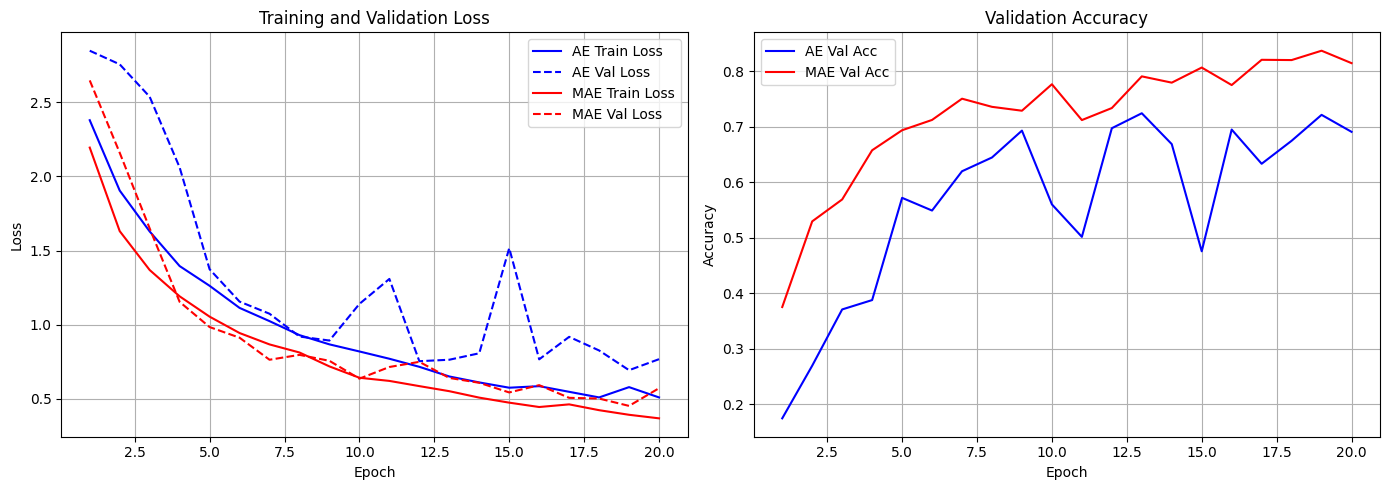

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_ae = range(1, len(train_losses_ae) + 1)
# epochs_ae20 = range(1, len(train_losses_ae20) + 1)
epochs_mae = range(1, len(train_losses_mae) + 1)
# epochs_mae20 = range(1, len(train_losses_mae20) + 1)

ax1.plot(epochs_ae, train_losses_ae, 'b-', label='AE Train Loss')
ax1.plot(epochs_ae, val_losses_ae, 'b--', label='AE Val Loss')
# ax1.plot(epochs_ae20, train_losses_ae20, 'y-', label='AE 20% Train Loss')
# ax1.plot(epochs_ae20, val_losses_ae20, 'y--', label='AE 20% Val Loss')
ax1.plot(epochs_mae, train_losses_mae, 'r-', label='MAE Train Loss')
ax1.plot(epochs_mae, val_losses_mae, 'r--', label='MAE Val Loss')
# ax1.plot(epochs_mae20, train_losses_mae20, 'g-', label='MAE 20% Train Loss')
# ax1.plot(epochs_mae20, val_losses_mae20, 'g--', label='MAE 20% Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_ae, val_accs_ae, 'b-', label='AE Val Acc')
# ax2.plot(epochs_ae20, val_accs_ae20, 'y-', label='AE 20% Val Acc')
ax2.plot(epochs_mae, val_accs_mae, 'r-', label='MAE Val Acc')
# ax2.plot(epochs_mae20, val_accs_mae20, 'g-', label='MAE 20% Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

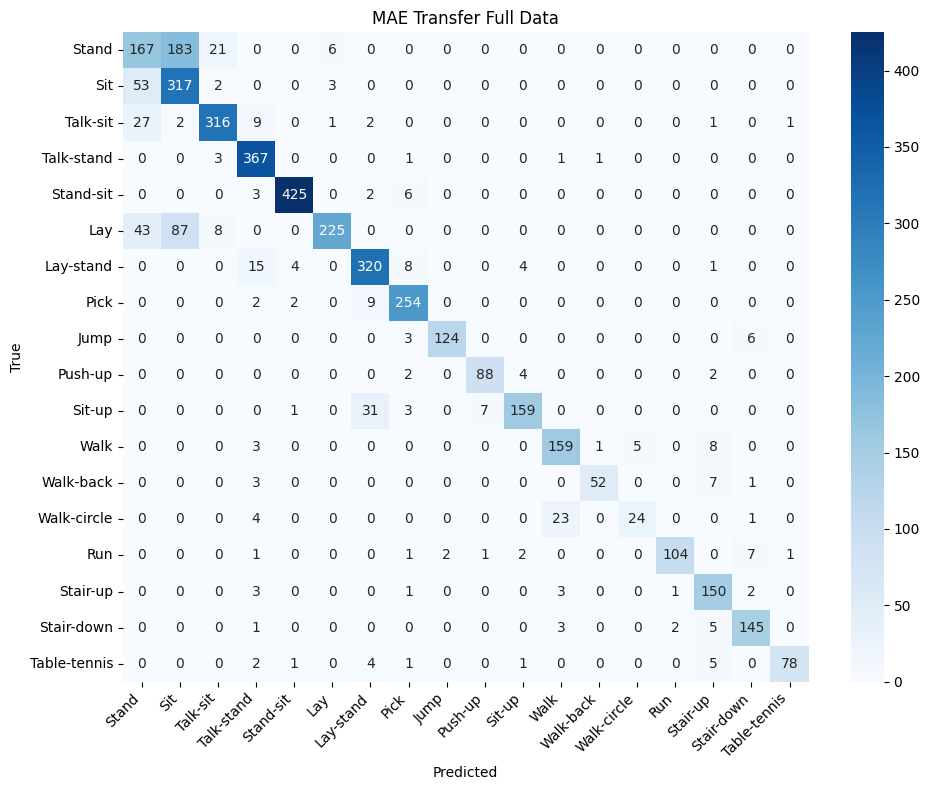

In [14]:
make_confusion(model, test_loader, title="MAE Transfer Full Data")
# make_confusion(model, test_loader, title="MAE Transfer 20% Data")